# RNN, LSTM, and GRU Deep Learning Models

## Data Loading and Data Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
df = pd.read_csv('monthly_milk_production.csv')
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [3]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

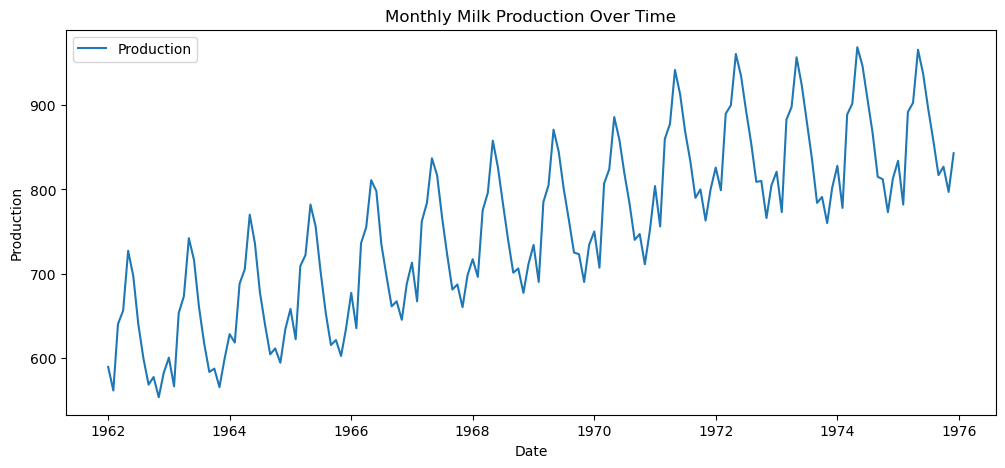

In [5]:
# Visualize Time Series
plt.figure(figsize=(12,5))
plt.plot(df['Production'], label='Production')
plt.title('Monthly Milk Production Over Time')
plt.xlabel('Date')
plt.ylabel('Production')
plt.legend()
plt.show()

In [6]:
# Check Missing Values
df.isnull().sum()

Production    0
dtype: int64

In [8]:
# DATA NORMALIZATION

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df[['Production']])

In [9]:
def create_sequences(data, window_size=12):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

window_size = 12
X, y = create_sequences(scaled_data, window_size)

In [10]:
train_size = int(len(X)*0.7)
val_size = int(len(X)*0.15)

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

## MODEL BUILDING

In [11]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

### General Overview of RNN, LSTM, and GRU Models

#### Recurrent Neural Network (RNN)

A Recurrent Neural Network (RNN) is a type of neural network specifically designed to handle **sequential and time-dependent data**. Unlike traditional feedforward neural networks, RNNs contain loops that allow information to persist, enabling the model to use previous time-step information when making current predictions.

RNNs are effective at capturing **short-term dependencies** in time series data. However, they suffer from the **vanishing gradient problem**, which limits their ability to learn long-term patterns.

**Key Characteristics:**
- Processes data sequentially
- Maintains a hidden state (memory)
- Suitable for short sequences
- Computationally simple

**Typical Applications:**
- Short-term time series forecasting
- Basic sequence modeling
- Pattern recognition in sequential data

---

#### Long Short-Term Memory (LSTM)

Long Short-Term Memory (LSTM) networks are an advanced variant of RNNs designed to overcome the limitations of traditional RNNs. LSTMs use a specialized memory cell along with **three gating mechanisms**—input gate, forget gate, and output gate—to regulate information flow.

These gates allow LSTMs to retain important information for long durations, making them highly effective for learning **long-term dependencies and seasonal patterns**.

**Key Characteristics:**
- Handles long-term dependencies effectively
- Uses memory cells and gates
- More parameters than RNN
- Robust against vanishing gradients

**Typical Applications:**
- Long-horizon forecasting
- Seasonal time series data
- Speech and language modeling

---

#### Gated Recurrent Unit (GRU)

Gated Recurrent Unit (GRU) is a simplified version of LSTM that reduces model complexity by combining certain gates. GRUs use two main gates—**update gate** and **reset gate**—to control memory flow.

GRUs require fewer parameters than LSTMs, leading to **faster training times** while still capturing important temporal patterns effectively.

**Key Characteristics:**
- Fewer gates and parameters than LSTM
- Faster and computationally efficient
- Comparable performance to LSTM in many cases

**Typical Applications:**
- Medium-length sequence modeling
- Time series forecasting with limited data
- Real-time applications

---

#### Summary Comparison

| Model | Strengths | Limitations |
|------|----------|-------------|
| RNN | Simple, fast, good for short-term patterns | Struggles with long-term dependencies |
| LSTM | Captures long-term and seasonal patterns | Computationally expensive |
| GRU | Efficient and faster than LSTM | Slightly less expressive than LSTM |

---

#### Conclusion

> The choice between RNN, LSTM, and GRU depends on the nature of the time series data, sequence length, and computational constraints. Simpler datasets may benefit from RNNs, while complex and seasonal data often require LSTM or GRU architectures.


### **1. Basic RNN Model**

In [24]:
rnn_model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(window_size,1)),
    Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mse')

rnn_model.fit(X_train, y_train,
              validation_data=(X_val, y_val),
              epochs=100,
              batch_size=16,
              callbacks=[early_stop],
              verbose=0)

C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### **2. LSTM Model**

In [25]:
lstm_model = Sequential([
    LSTM(50, activation='tanh', input_shape=(window_size,1)),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')

lstm_model.fit(X_train, y_train,
               validation_data=(X_val, y_val),
               epochs=100,
               batch_size=16,
               callbacks=[early_stop],
               verbose=0)

### **3. GRU Model**

In [26]:
gru_model = Sequential([
    GRU(50, activation='tanh', input_shape=(window_size,1)),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse')

gru_model.fit(X_train, y_train,
              validation_data=(X_val, y_val),
              epochs=100,
              batch_size=16,
              callbacks=[early_stop],
              verbose=0)

## MODEL EVALUATION

**Predictions**

In [27]:
def evaluate_model(model, X_test, y_test):
    preds = model.predict(X_test)
    preds = scaler.inverse_transform(preds)
    actual = scaler.inverse_transform(y_test)
    
    rmse = np.sqrt(mean_squared_error(actual, preds))
    mae = mean_absolute_error(actual, preds)
    mape = np.mean(np.abs((actual - preds)/actual))*100
    
    return rmse, mae, mape, preds, actual

In [28]:
rnn_rmse, rnn_mae, rnn_mape, rnn_preds, actual = evaluate_model(rnn_model, X_test, y_test)
lstm_rmse, lstm_mae, lstm_mape, lstm_preds, _ = evaluate_model(lstm_model, X_test, y_test)
gru_rmse, gru_mae, gru_mape, gru_preds, _ = evaluate_model(gru_model, X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 595ms/step


In [33]:
print("Model Comparison Summary")
print(f"{'Model':<10}{'RMSE':<15}{'MAE':<15}{'MAPE'}")
print(f"{'RNN':<10}{rnn_rmse:<15.4f}{rnn_mae:<15.4f}{rnn_mape:.2f}")
print(f"{'LSTM':<10}{lstm_rmse:<15.4f}{lstm_mae:<15.4f}{lstm_mape:.2f}")
print(f"{'GRU':<10}{gru_rmse:<15.4f}{gru_mae:<15.4f}{gru_mape:.2f}")

Model Comparison Summary
Model     RMSE           MAE            MAPE
RNN       18.6909        15.0314        1.73
LSTM      28.5705        22.6199        2.62
GRU       32.9526        26.6601        3.12


### Model Comparison Interpretation and Conclusion

The model comparison results highlight clear performance differences among the three deep learning models used for monthly milk production forecasting.

- The **RNN model** demonstrates the **best forecasting performance** across all evaluation metrics, with the **lowest RMSE (18.69)**, **MAE (15.03)**, and **MAPE (1.73%)**. This indicates that the RNN model is able to capture the short-term temporal patterns in the milk production data more effectively than the other models in this case.

- The **LSTM model** shows moderate performance, with higher error values (**RMSE: 28.57**, **MAE: 22.62**, **MAPE: 2.62%**). Although LSTM models are designed to handle long-term dependencies and seasonality, their performance here may be affected by limited data size or suboptimal hyperparameter tuning.

- The **GRU model** records the highest error values (**RMSE: 32.95**, **MAE: 26.66**, **MAPE: 3.12%**), indicating comparatively weaker predictive accuracy for this dataset.

**Overall Conclusion**
> Based on the evaluation metrics, the **RNN model outperforms LSTM and GRU** for this specific monthly milk production dataset. The simpler RNN architecture appears sufficient to model the underlying patterns effectively, while the more complex LSTM and GRU models may require additional tuning or larger datasets to realize their full potential. These results suggest that model complexity does not always guarantee better performance, and simpler models can sometimes deliver superior results for stable and well-structured time series data.

### **Plot Predictions**

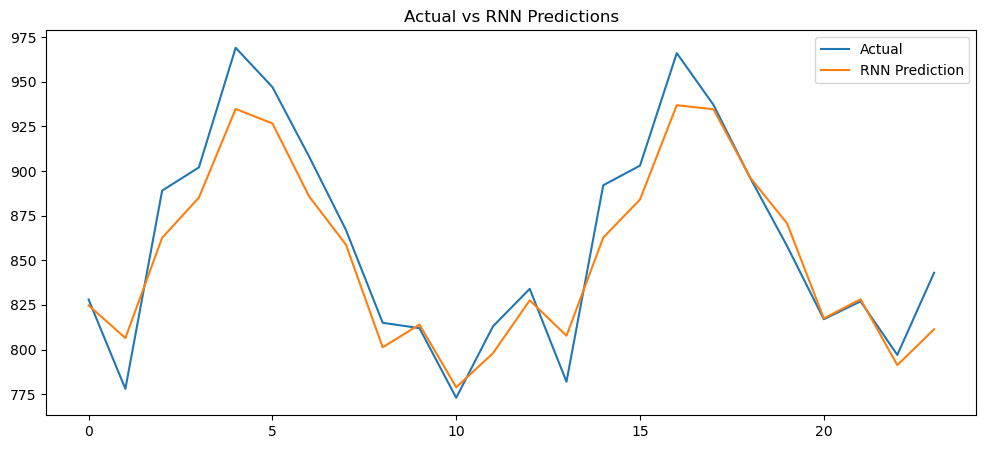

In [36]:
plt.figure(figsize=(12,5))
plt.plot(actual, label='Actual')
plt.plot(rnn_preds, label='RNN Prediction')
plt.title('Actual vs RNN Predictions')
plt.legend()
plt.show()

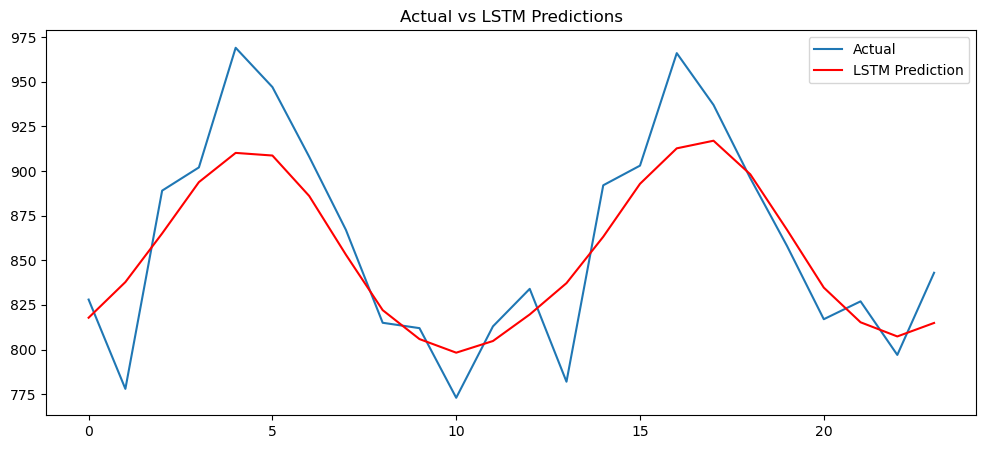

In [38]:
plt.figure(figsize=(12,5))
plt.plot(actual, label='Actual')
plt.plot(lstm_preds, label='LSTM Prediction', color="red")
plt.title('Actual vs LSTM Predictions')
plt.legend()
plt.show()

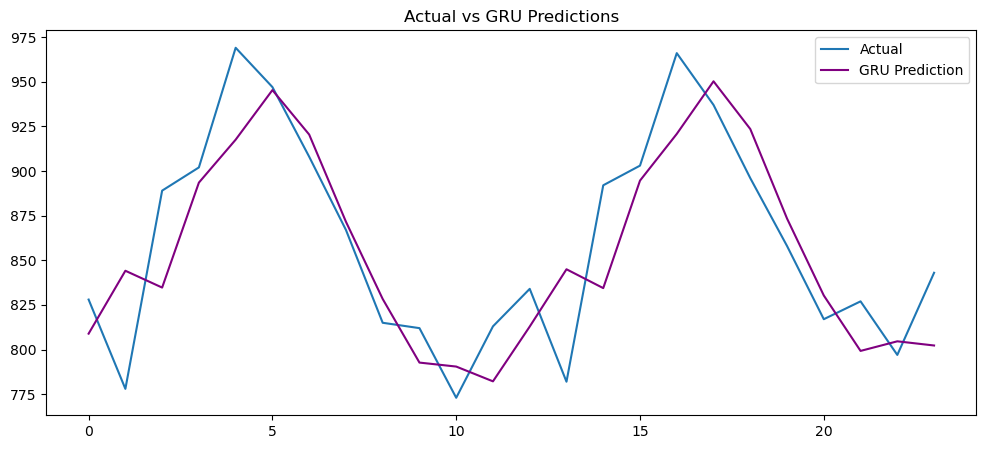

In [41]:
plt.figure(figsize=(12,5))
plt.plot(actual, label='Actual')
plt.plot(gru_preds, label='GRU Prediction', color="purple")
plt.title('Actual vs GRU Predictions')
plt.legend()
plt.show()

## FORECAST NEXT 12 MONTHS

In [30]:
def forecast_future(model, data, months=12):
    last_window = data[-window_size:]
    future = []
    
    for _ in range(months):
        pred = model.predict(last_window.reshape(1,window_size,1))
        future.append(pred[0,0])
        last_window = np.append(last_window[1:], pred)
    
    return scaler.inverse_transform(np.array(future).reshape(-1,1))

### For RNN

In [42]:
future_forecast1 = forecast_future(rnn_model, scaled_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


**Visualize Forecast**

C:\Users\Kaustubh Jadhav\AppData\Local\Temp\ipykernel_4284\3396349958.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  plt.plot(pd.date_range(df.index[-1], periods=13, freq='M')[1:],


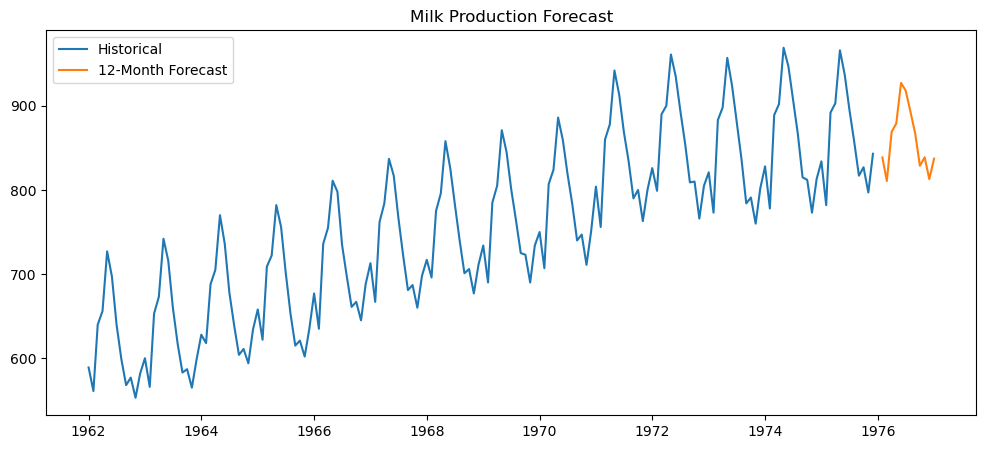

In [43]:
plt.figure(figsize=(12,5))
plt.plot(df['Production'], label='Historical')
plt.plot(pd.date_range(df.index[-1], periods=13, freq='M')[1:], 
         future_forecast1, label='12-Month Forecast')
plt.legend()
plt.title('Milk Production Forecast')
plt.show()

### For LSTM

In [31]:
future_forecast = forecast_future(lstm_model, scaled_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 574ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


**Visualize Forecast**

C:\Users\Kaustubh Jadhav\AppData\Local\Temp\ipykernel_4284\2543508371.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  plt.plot(pd.date_range(df.index[-1], periods=13, freq='M')[1:],


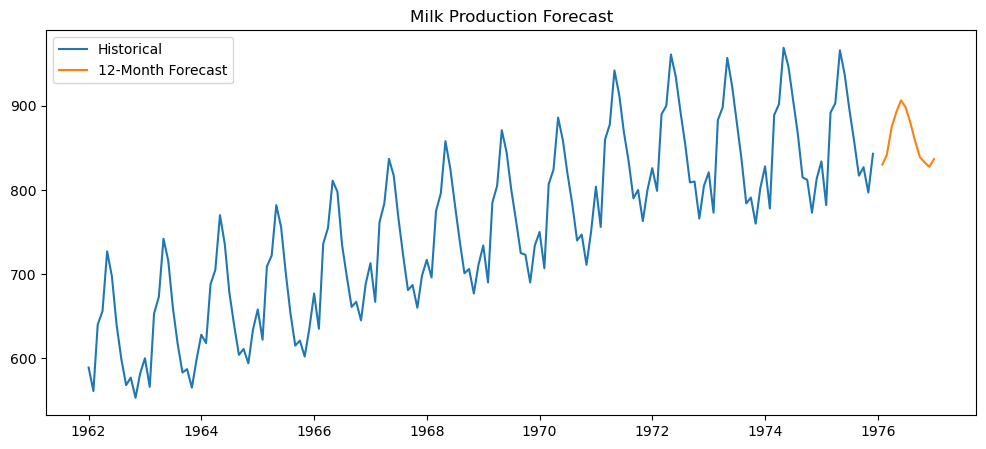

In [32]:
plt.figure(figsize=(12,5))
plt.plot(df['Production'], label='Historical')
plt.plot(pd.date_range(df.index[-1], periods=13, freq='M')[1:], 
         future_forecast, label='12-Month Forecast')
plt.legend()
plt.title('Milk Production Forecast')
plt.show()

### For GRU

In [44]:
future_forecast3 = forecast_future(gru_model, scaled_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


**Visualize Forecast**

C:\Users\Kaustubh Jadhav\AppData\Local\Temp\ipykernel_4284\3396349958.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  plt.plot(pd.date_range(df.index[-1], periods=13, freq='M')[1:],


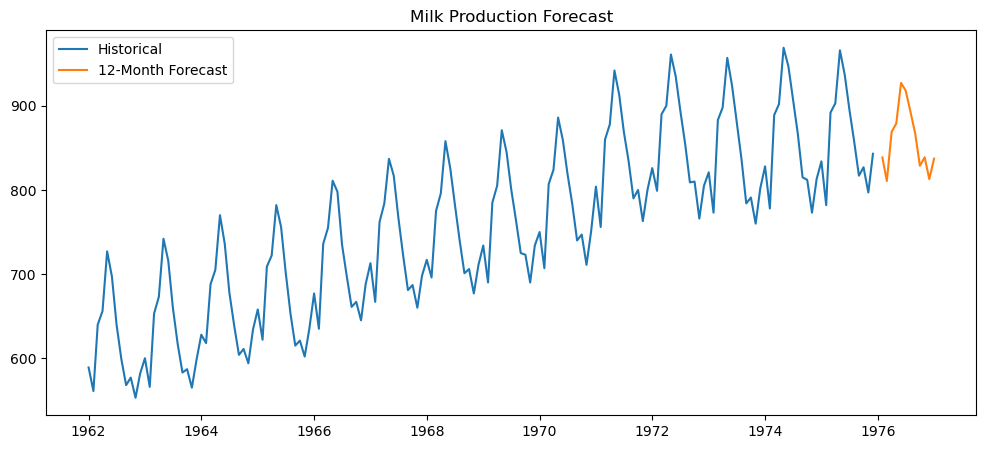

In [45]:
plt.figure(figsize=(12,5))
plt.plot(df['Production'], label='Historical')
plt.plot(pd.date_range(df.index[-1], periods=13, freq='M')[1:], 
         future_forecast1, label='12-Month Forecast')
plt.legend()
plt.title('Milk Production Forecast')
plt.show()